# Proyecto de Estadística: EDA Profesional de Clientes
Este notebook consolida un flujo completo de Limpieza Avanzada de Datos, Análisis Estadístico Riguroso y Visualización Dinámica utilizando **Programación Orientada a Objetos (POO)** y **Herencia** en Python.

## 1. Importación de Módulos Modulares de `eda_package`

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Importación de clases orientadas a objetos
from eda_package import DataLoader, DataCleaner, StatisticalAnalysis, Visualizer

## 2. Ingesta y Limpieza de Alta Precisión
Aquí se manejan outliers extremos causados por errores humanos de digitación (como ingresos mensuales de $25M), se eliminan duplicados, se corrigen signos negativos incorrectos y se imputan valores nulos de forma robusta.

In [18]:
# Carga
loader = DataLoader("clientes_dirty_semana2.csv")
df_raw = loader.load_data()

# Limpieza con la clase DataCleaner (Hereda de BaseDataProcessor)
cleaner = DataCleaner(df_raw)
df_clean = cleaner.execute_pipeline()
df_clean.head()

Dataset cargado exitosamente. Filas: 772, Columnas: 19
Removidas 6 filas duplicadas.
Pipeline de limpieza finalizado exitosamente.


,id_cliente,nombre_cliente,edad,genero,pais,ciudad,segmento,nivel_satisfaccion,ingresos_mensuales,compras_ultimos_6m,monto_total_compras,fecha_registro,canal_preferido,reclamos_ultimos_6m,tiempo_entrega_dias,estado_cliente,score_riesgo,email,telefono
0,C0001,Natalia Vargas,43.0,masculino,el salvador,San José,Bronce,Muy alto,501099.0,8,164519.0,2024-04-04 00:00:00,WhatsApp,2.0,5.8,bloqueado,688.0,nataliavargas@correo.com,61849593
1,C0002,Adriana Torres,57.0,masculino,Nicaragua,Puntarenas,Oro,Bajo,938129.0,7,277828.0,2026-02-25 00:00:00,Correo,0.0,4.6,activo,377.0,adrianatorres@correo.com,53767242
2,C0003,Pablo Monge,19.0,femenino,Guatemala,Alajuela,Oro,Muy alto,956439.0,10,0.0,2025-07-03 00:00:00,Llamada,0.0,3.2,activo,252.0,pablomonge@correo.com,82814893
3,C0004,Emilio Aguilar,28.0,femenino,Panamá,Cartago,Desconocido,Medio,490545.0,8,138229.0,2024-07-24 00:00:00,WhatsApp,7.0,5.5,bloqueado,561.0,emilioaguilar@correo.com,50983930
4,C0005,María Mora,36.0,masculino,Guatemala,Desconocido,Premium,Medio,338284.0,6,155090.0,2026-03-30 00:00:00,llamada,0.0,5.8,Desconocido,417.0,mariamora@correo.com,78108013


## 3. Análisis Estadístico Descriptivo
Cálculo de medidas de tendencia central (media, mediana, moda), dispersión (desviación estándar) y forma (asimetría/skewness, curtosis).

In [19]:
stats = StatisticalAnalysis(df_clean)
resultados = stats.run_full_analysis()

print("--- Estadísticas Básicas ---")
display(resultados["Estadísticas Básicas"])

print("\n--- Forma de la Distribución (Asimetría y Curtosis) ---")
display(resultados["Forma de la Distribución"])

--- Estadísticas Básicas ---


,Media,Mediana,Desv_Estandar,Moda
edad,3.425326e+01,34.0,1.027611e+01,34.0
ingresos_mensuales,1.174767e+06,829030.0,2.393286e+06,829030.0
compras_ultimos_6m,1.146606e+01,7.0,3.064916e+01,0.0
monto_total_compras,4.229819e+05,155090.0,1.604996e+06,155090.0
reclamos_ultimos_6m,1.950392e+00,1.0,7.981196e+00,0.0
tiempo_entrega_dias,5.693995e+00,4.8,9.387324e+00,3.5
score_riesgo,5.495705e+02,547.0,1.918127e+02,547.0



--- Forma de la Distribución (Asimetría y Curtosis) ---


,Skewness (Pandas),Kurtosis (Pandas)
edad,0.383266,-0.185801
ingresos_mensuales,8.767440,80.502207
compras_ultimos_6m,7.699275,64.205223
monto_total_compras,7.471377,59.195410
reclamos_ultimos_6m,8.126651,69.353480
tiempo_entrega_dias,10.117661,115.693270
score_riesgo,-0.222061,0.499215


### Detección Matemática de Outliers (IQR)
Evaluamos si existen outliers significativos utilizando la técnica de rango intercuartílico.

In [20]:
outliers_edad = stats.detect_outliers_iqr("edad")
print(f"Límites lógicos de edad: {outliers_edad['lower_bound']} a {outliers_edad['upper_bound']}")
print(f"Cantidad de outliers en edad: {outliers_edad['outliers_count']}")

Límites lógicos de edad: 6.0 a 62.0
Cantidad de outliers en edad: 4


## 4. Análisis de Correlación de Pearson

In [21]:
print("--- Correlación de Pearson (Lineal) ---")
display(resultados["Correlaciones"])
print("\n--- Correlación de Spearman (Monotónica) ---")
display(resultados["Correlaciones Spearman"])


,edad,ingresos_mensuales,compras_ultimos_6m,monto_total_compras,reclamos_ultimos_6m,tiempo_entrega_dias,score_riesgo
edad,1.000000,-0.074490,-0.031495,-0.012404,-0.024248,-0.024715,-0.037458
ingresos_mensuales,-0.074490,1.000000,-0.017670,0.053163,-0.005942,-0.005776,0.016665
compras_ultimos_6m,-0.031495,-0.017670,1.000000,0.465264,-0.016081,0.010912,-0.061539
monto_total_compras,-0.012404,0.053163,0.465264,1.000000,-0.020963,-0.014546,-0.034705
reclamos_ultimos_6m,-0.024248,-0.005942,-0.016081,-0.020963,1.000000,-0.025065,0.009702
tiempo_entrega_dias,-0.024715,-0.005776,0.010912,-0.014546,-0.025065,1.000000,-0.036951
score_riesgo,-0.037458,0.016665,-0.061539,-0.034705,0.009702,-0.036951,1.000000


## 5. Visualizaciones Estadísticas Estáticas
Generación de histogramas, boxplots y heatmaps estáticos en el notebook.

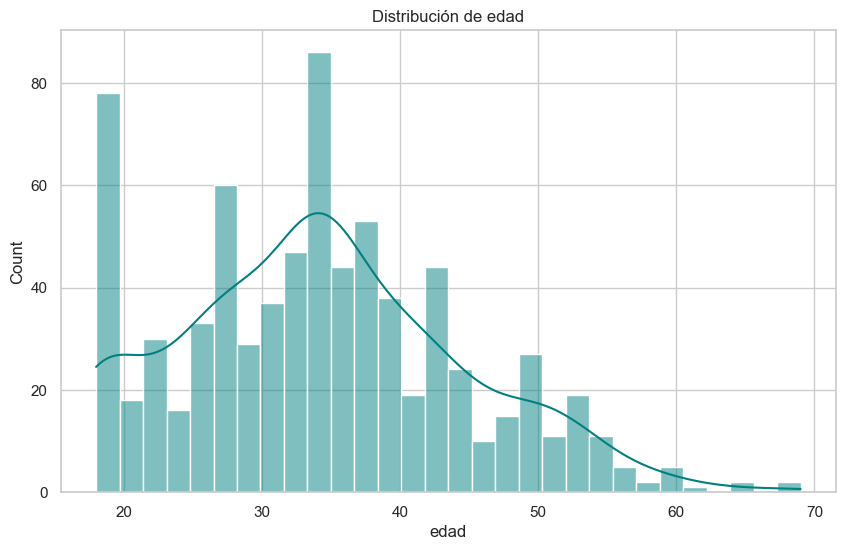

In [22]:
vis = Visualizer(df_clean)

# Histograma de edad con KDE
vis.plot_histogram("edad", interactive=False)

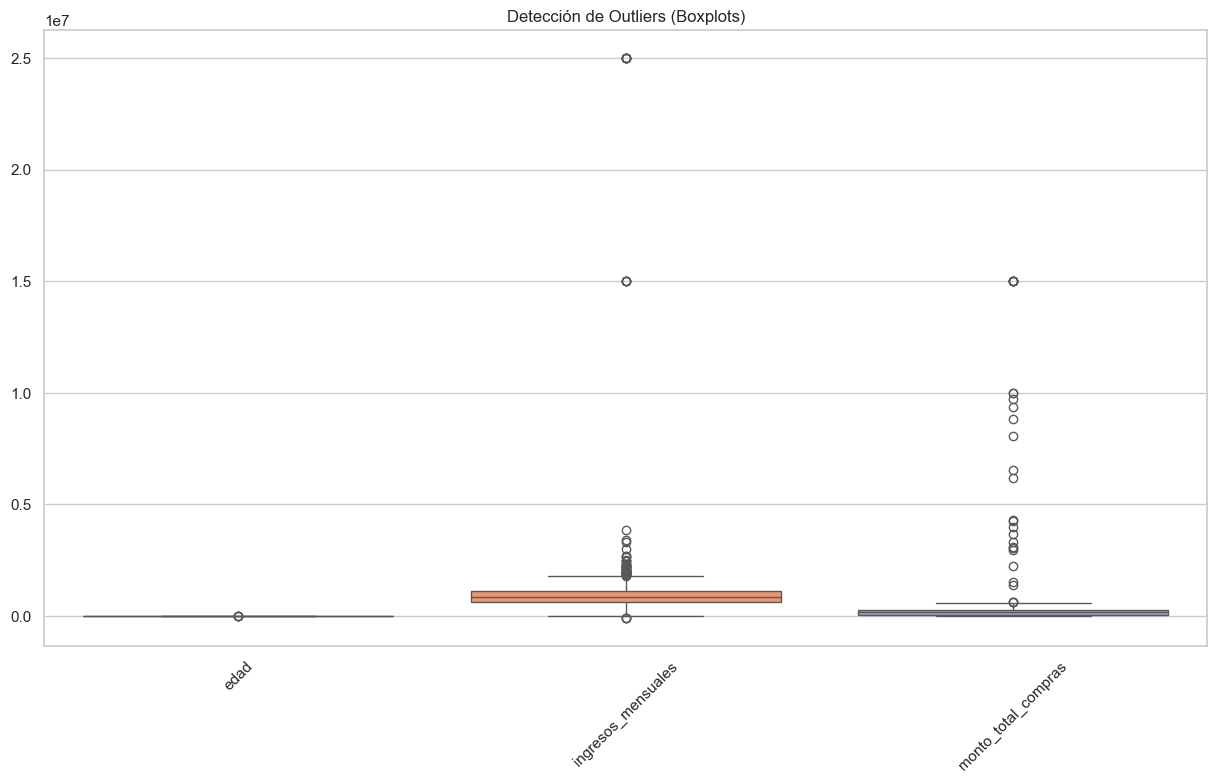

In [23]:
# Boxplots para validar distribución
vis.plot_boxplots(columns=["edad", "ingresos_mensuales", "monto_total_compras"], interactive=False)

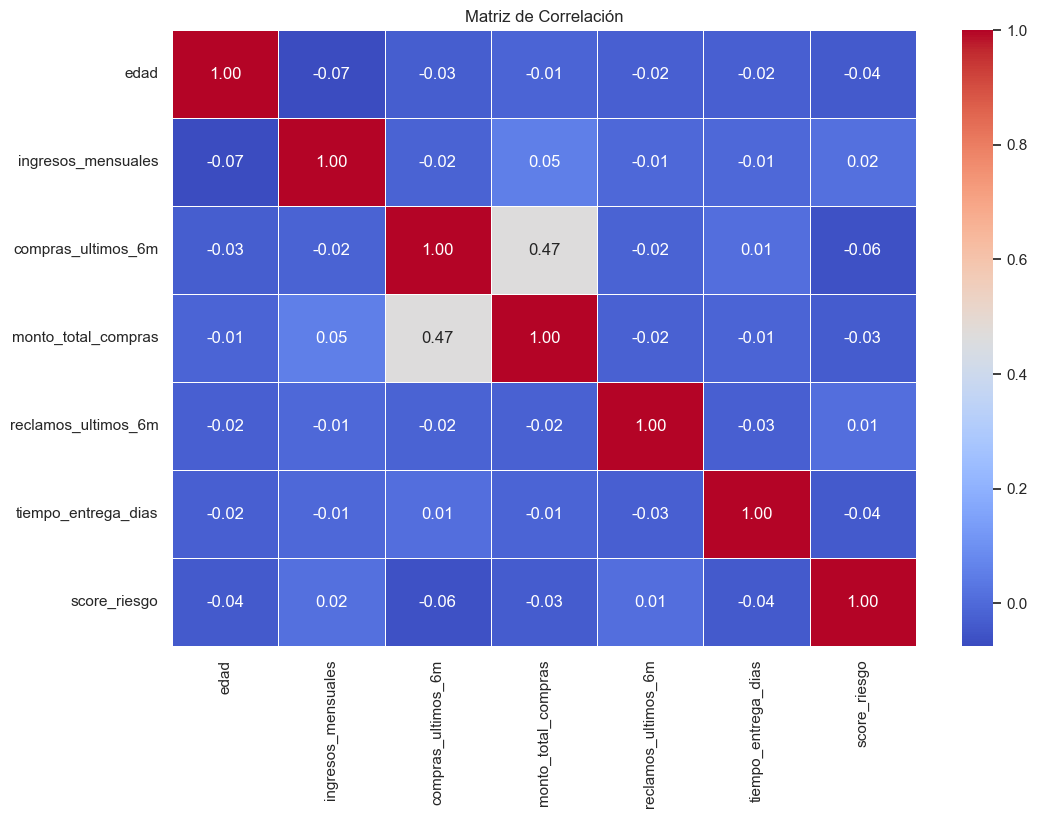

In [24]:
# Heatmap de correlación lineal (Pearson)
print("Matriz de Correlación (Pearson):")
vis.plot_correlation_matrix(interactive=False, method="pearson")

# Heatmap de correlación de rangos (Spearman)
print("\nMatriz de Correlación (Spearman):")
vis.plot_correlation_matrix(interactive=False, method="spearman")
